In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree


In [2]:
import sys
sys.path.append("/home/z5297792/ESP_zonodo") 
from functions import doppio, doppio_pipeliner

from clim_functions import nencioli


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

res = 1  # 1 km resolution
x_new = np.arange(0, x_grid[-1], res)
y_new = np.arange(0, y_grid[-1], res)
X_new, Y_new = np.meshgrid(x_new, y_new, indexing='ij')
new_points = np.column_stack((X_new.ravel(), Y_new.ravel()))

interp_lon = RegularGridInterpolator((x_grid, y_grid), lon_rho,
                                     method='linear', bounds_error=False, fill_value=np.nan)
interp_lat = RegularGridInterpolator((x_grid, y_grid), lat_rho,
                                     method='linear', bounds_error=False, fill_value=np.nan)

lon_new = interp_lon(new_points).reshape(len(x_new), len(y_new))
lat_new = interp_lat(new_points).reshape(len(x_new), len(y_new))


In [4]:
def interpolate_uv(u, v, X_new, Y_new, angle):
    x_new, y_new = X_new[:,0], Y_new[0,:]

    u_east = np.where(np.abs(u) > 1e30, np.nan, u).astype(float)
    v_north = np.where(np.abs(v) > 1e30, np.nan, v).astype(float)

    u_rot = v_north * np.sin(angle) + u_east * np.cos(angle)
    v_rot = v_north * np.cos(angle) - u_east * np.sin(angle)

    shape_new = X_new.shape
    new_points = np.column_stack((X_new.ravel(), Y_new.ravel()))

    interp_u = RegularGridInterpolator((x_grid, y_grid), u_rot,
                                       method='linear', bounds_error=False, fill_value=np.nan)
    interp_v = RegularGridInterpolator((x_grid, y_grid), v_rot,
                                       method='linear', bounds_error=False, fill_value=np.nan)

    u_new = interp_u(new_points).reshape(shape_new)
    v_new = interp_v(new_points).reshape(shape_new)

    return u_new, v_new


Apply Nencioli (with data inteproalted to 1km). Apply it 1 day at a time, constantly saving the newly updated df. 

,Day,nxc,nyc,nic,njc,Cyc
0,1462,830.0,1515.0,245,307,AE
1,1462,358.0,1408.0,136,285,AE
2,1462,928.0,1356.0,261,274,CE
3,1462,506.0,1354.0,179,274,CE
4,1462,754.0,1285.0,231,260,AE
5,1462,417.0,1135.0,155,230,CE
6,1462,447.0,1024.0,164,207,AE
7,1462,841.0,972.0,246,197,AE
8,1462,898.0,919.0,256,186,AE
9,1462,649.0,906.0,211,184,CE


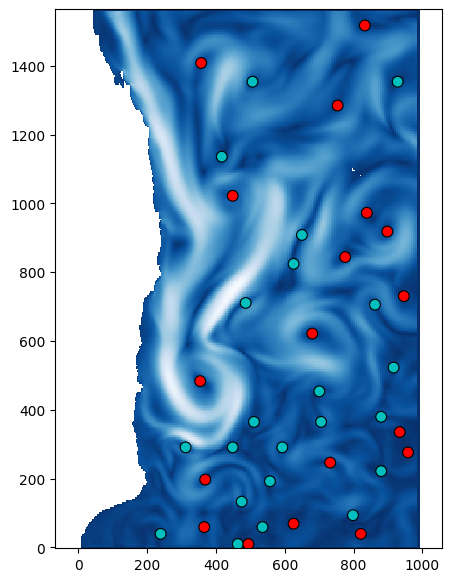

In [56]:
day = 1462
fnumber = 1461 + ((day - 1462) // 30)*30
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
dataset = nc.Dataset(fname)
u_east = np.transpose(dataset['u_eastward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
v_north = np.transpose(dataset['v_northward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
ocean_time = dataset.variables['ocean_time'][:].data / 86400
t = np.where(day==ocean_time)[0][0]

# if t.size != 0:
u, v = u_east[:, :, t], v_north[:, :, t]
u0, v0 = interpolate_uv(u, v, X_new, Y_new, angle)

neddy = nencioli(u0.T, v0.T, X_new.T, Y_new.T, 4, 3)[2]
neddy = neddy[neddy[:, 1].argsort()[::-1]]

df_nenc = pd.DataFrame(columns=['Day', 'nxc', 'nyc', 'nic', 'njc', 'Cyc'])

df_nenc['Day'] = [day] * len(neddy)
df_nenc['nxc'] = neddy[:,0]
df_nenc['nyc'] = neddy[:,1]

# find nearest i, j 
points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))
tree = cKDTree(points)
_, idx = tree.query(neddy[:,:2])  # neddy = (N, 2)
nics, njcs = np.unravel_index(idx, X_grid.shape)
df_nenc['nic'] = nics
df_nenc['njc'] = njcs

df_nenc['Cyc'] = np.where(neddy[:, 2] == -1, 'CE', 'AE')

plt.figure(figsize=(5, 7))
cs = np.where(np.abs(np.hypot(u, v)) > 1e30, np.nan, np.hypot(u, v))
plt.pcolor(X_grid, Y_grid, cs, cmap='Blues_r')
plt.axis('equal')
# clrs = np.array(['r'] * len(neddy))
# clrs[neddy[:,2]==-1] = 'c'
# plt.scatter(neddy[:,0], neddy[:,1], color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

clrs = np.array(['r'] * len(df_nenc))
clrs[df_nenc.Cyc=='CE'] = 'c'
# plt.scatter(df_nenc.nxc, df_nenc.nyc, color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)
plt.scatter(X_grid[df_nenc.nic, df_nenc.njc], Y_grid[df_nenc.nic, df_nenc.njc], color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

df_nenc


In [64]:
def get_nencioli_30day_df(start_day, X_new, Y_new, X_grid, Y_grid, angle,
                          a=4, b=3,
                          path='/srv/scratch/z3533156/26year_BRAN2020',
                          plot=False):
    
    fnumber = 1461 + ((start_day - 1462) // 30) * 30
    fname = f'{path}/outer_avg_{fnumber:05}.nc'
    
    dataset = nc.Dataset(fname)
    u_east = np.transpose(dataset['u_eastward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
    v_north = np.transpose(dataset['v_northward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
    ocean_time = dataset.variables['ocean_time'][:].data / 86400
    
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))  # original grid points for nearest i, j
    tree = cKDTree(points)

    dfs = []

    for day in range(start_day, start_day + 30):
        t = np.where(day == ocean_time)[0]

        if len(t) == 0:
            continue  # skip missing days

        t = t[0]
        u, v = u_east[:, :, t], v_north[:, :, t]
        u0, v0 = interpolate_uv(u, v, X_new, Y_new, angle)

        neddy = nencioli(u0.T, v0.T, X_new.T, Y_new.T, a, b)[2]

        if len(neddy) == 0:
            continue  # skip days with no detected eddies

        neddy = neddy[neddy[:, 1].argsort()[::-1]]

        df_nenc = pd.DataFrame({
            'Day': day,
            'nxc': neddy[:, 0],
            'nyc': neddy[:, 1],
            'Cyc': np.where(neddy[:, 2] == -1, 'CE', 'AE')
        })

        _, idx = tree.query(neddy[:, :2])  # nearest original-grid point to each detected centre
        nics, njcs = np.unravel_index(idx, X_grid.shape)

        df_nenc['nic'] = nics
        df_nenc['njc'] = njcs

        dfs.append(df_nenc)

        if plot:
            if day == start_day + 15:
                plt.figure(figsize=(5, 7))
                cs = np.where(np.abs(np.hypot(u, v)) > 1e30, np.nan, np.hypot(u, v))
                plt.pcolor(X_grid, Y_grid, cs, cmap='Blues_r')
                plt.axis('equal')
    
                clrs = np.array(['r'] * len(df_nenc))
                clrs[df_nenc.Cyc == 'CE'] = 'c'
    
                plt.scatter(df_nenc.nxc, df_nenc.nyc, color=clrs,
                            edgecolors='k', linewidths=0.8, s=60, zorder=10)
    
                plt.title(f'Day {day}')
                plt.show()

    dataset.close()

    if len(dfs) == 0:
        return pd.DataFrame(columns=['Day', 'nxc', 'nyc', 'Cyc', 'nic', 'njc'])

    return pd.concat(dfs, ignore_index=True)


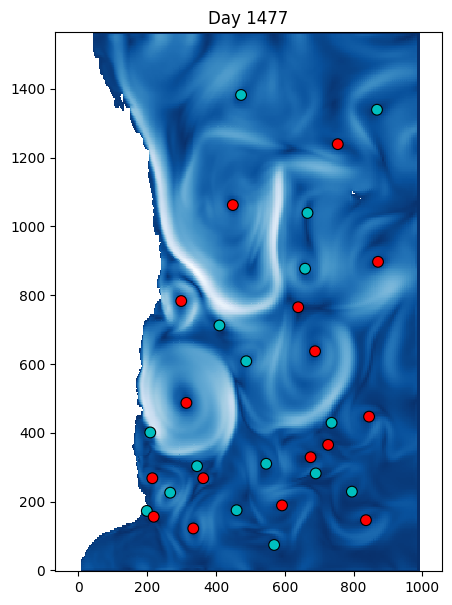

In [65]:
df_nenc_30 = get_nencioli_30day_df(
    start_day=1462,
    X_new=X_new,
    Y_new=Y_new,
    X_grid=X_grid,
    Y_grid=Y_grid,
    angle=angle,
    plot=True
)


In [66]:
df_nenc_30

,Day,nxc,nyc,Cyc,nic,njc
0,1462,830.0,1515.0,AE,245,307
1,1462,358.0,1408.0,AE,136,285
2,1462,928.0,1356.0,CE,261,274
3,1462,506.0,1354.0,CE,179,274
4,1462,754.0,1285.0,AE,231,260
...,...,...,...,...,...,...
1138,1491,640.0,109.0,AE,209,22
1139,1491,567.0,106.0,CE,193,22
1140,1491,979.0,101.0,CE,269,20
1141,1491,286.0,53.0,AE,109,11
